# Credit Card Fraud Detection using Machine Learning Techniques

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Veri seti incelendiğinde toplamda 284,807 adet işlem ve 31 adet değişken bulunduğu görülmektedir. Bu değişkenlerden 30 tanesi bağımsız değişken (feature), 1 tanesi ise hedef değişken (Class) olarak tanımlanmıştır.

Tüm değişkenlerde eksik veri (missing value) bulunmamaktadır, bu durum veri temizleme sürecini kolaylaştırmakta ve modelleme aşamasında ek bir imputasyon işlemine ihtiyaç duyulmadığını göstermektedir.

In [ ]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Veri setindeki sınıf dağılımı incelendiğinde, işlemlerin büyük çoğunluğunun normal (Class = 0) olduğu, sahte (fraud) işlemlerin ise oldukça az sayıda olduğu görülmektedir.

Toplam 284,807 işlemden yalnızca 492 tanesi (%0.17) fraud işlem olup, geri kalan %99.83’lük kısmı normal işlemlerden oluşmaktadır.

Bu durum veri setinin yüksek derecede dengesiz (imbalanced) olduğunu açıkça göstermektedir.




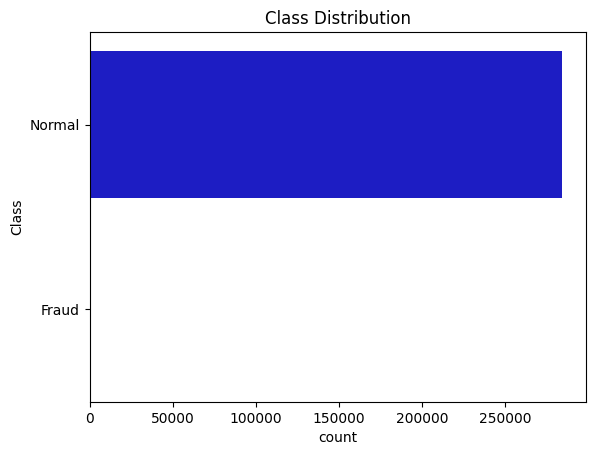

In [ ]:
colors = ["#0101DF", "#DF0101"]
sns.countplot(y='Class', data=df, palette=colors)
plt.title('Class Distribution')
plt.yticks([0,1], ['Normal', 'Fraud'])
plt.show()

# İşlemlerin Amount/Time'e Göre Dağılım İncelemsi

In [ ]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


Sınıflara göre işlem tutarları incelendiğinde, fraud işlemlerin ortalama değerinin normal işlemlerden daha yüksek olduğu görülmektedir. Ancak medyan değerler incelendiğinde fraud işlemlerin genellikle daha düşük tutarlı olduğu dikkat çekmektedir.

Bu durum, fraud veri dağılımının simetrik olmadığını ve birkaç yüksek değerli işlem nedeniyle ortalamanın yükseldiğini göstermektedir.

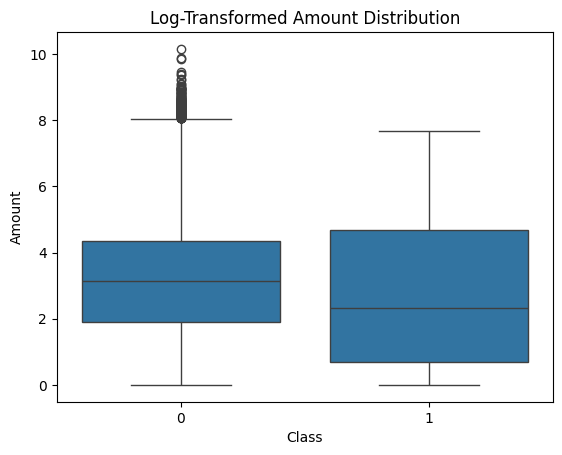

In [ ]:
sns.boxplot(x='Class', y=np.log1p(df['Amount']), data=df)
plt.title("Log-Transformed Amount Distribution")
plt.show()

İşlem tutarlarının sınıflara göre dağılımı incelendiğinde, Dolandırıcılık işlemleri genellikle daha düşük tutarlarda gerçekleşmektedir, ancak veri içerisinde yüksek tutarlı dolandırıcılık örnekleri de bulunmaktadır. Bu durum, işlem tutarının tek başına dolandırıcılığı belirlemek için yeterli olmadığını ve problemin daha karmaşık olduğunu göstermektedir.

Log dönüşümü, yüksek değerlerin etkisini azaltarak veri setindeki uç değerlerin baskınlığını düşürmüş ve dağılımın daha simetrik bir yapıya yaklaşmasını sağlamıştır.

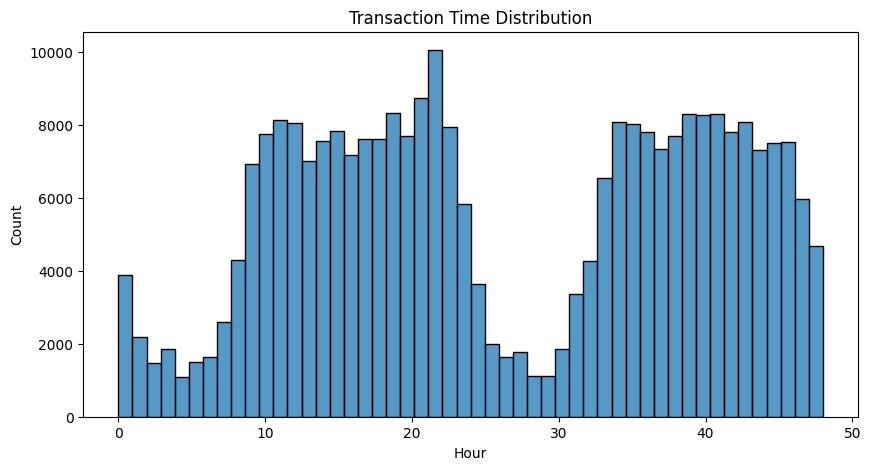

In [ ]:
plt.figure(figsize=(10,5))
df['Hour'] = (df['Time'] / 3600)
sns.histplot(df['Hour'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

Burda feature olan time'ı saat bazında çevirdim. 48 saat boyunca yapılan işlem sayısını görselleştirdim.

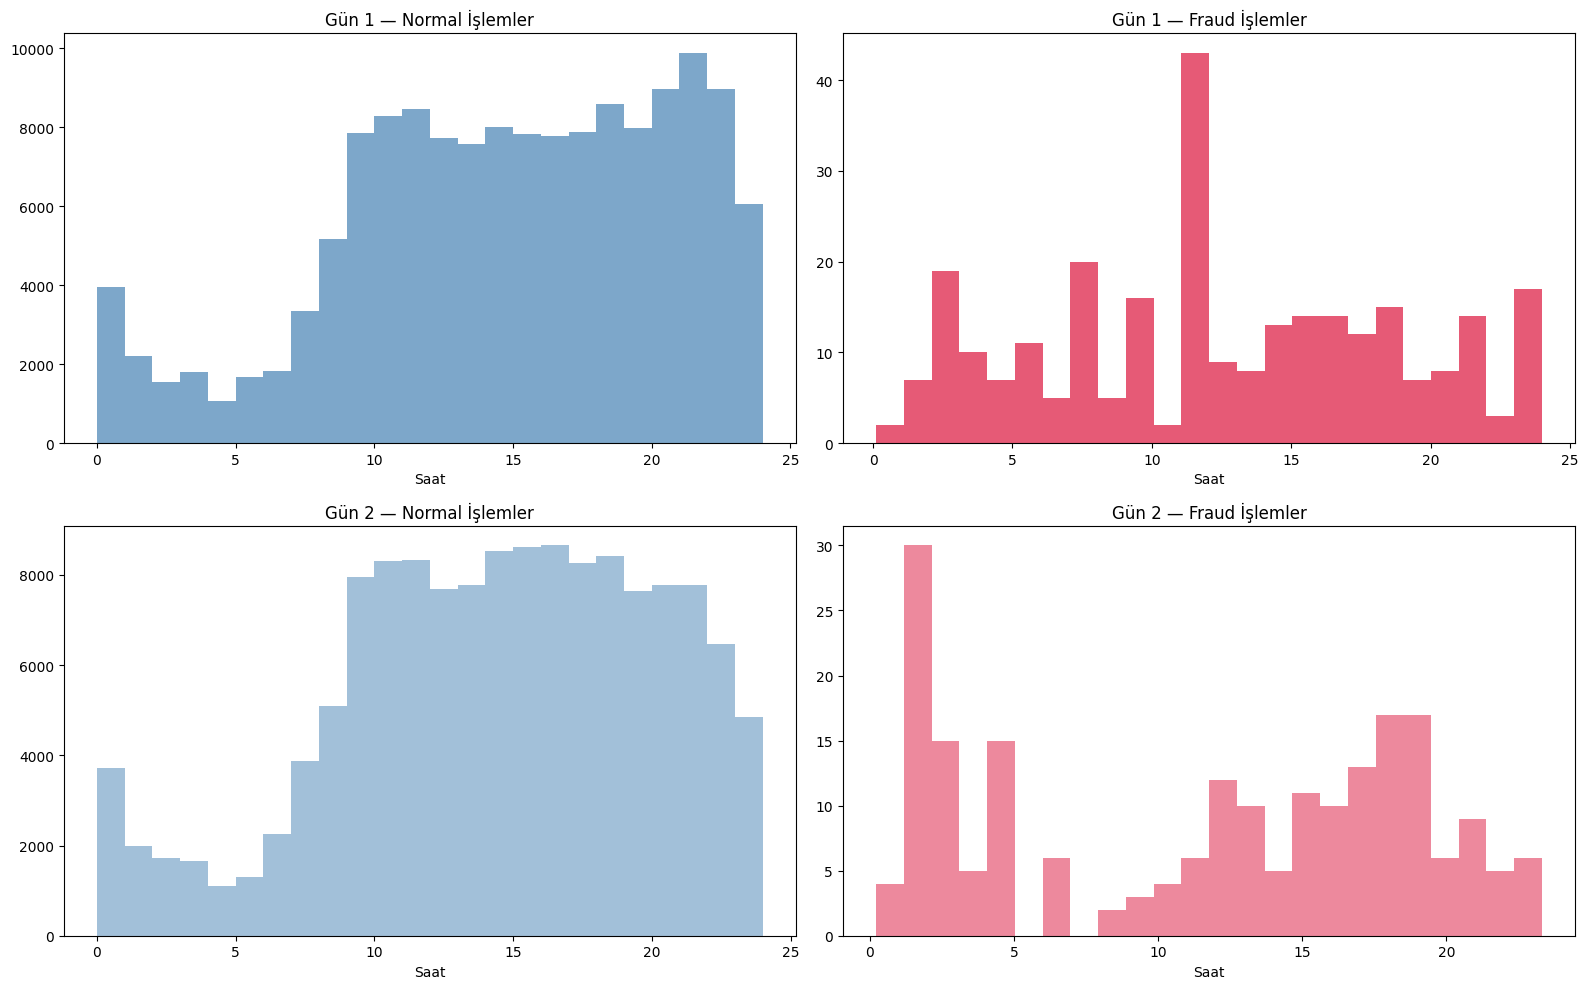

In [ ]:
# Gün 1: 0-24 saat, Gün 2: 24-48 saat
day1 = df[df['Hour'] < 24].copy()
day2 = df[df['Hour'] >= 24].copy()

# Gün 2'nin saatini 0-24'e normalize et
day2['Hour'] = day2['Hour'] - 24

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- GÜN 1 ---
axes[0][0].hist(day1[day1['Class']==0]['Hour'],
                bins=24, color='steelblue', alpha=0.7)
axes[0][0].set_title('Gün 1 — Normal İşlemler')
axes[0][0].set_xlabel('Saat')

axes[0][1].hist(day1[day1['Class']==1]['Hour'],
                bins=24, color='crimson', alpha=0.7)
axes[0][1].set_title('Gün 1 — Fraud İşlemler')
axes[0][1].set_xlabel('Saat')

# --- GÜN 2 ---
axes[1][0].hist(day2[day2['Class']==0]['Hour'],
                bins=24, color='steelblue', alpha=0.5)
axes[1][0].set_title('Gün 2 — Normal İşlemler')
axes[1][0].set_xlabel('Saat')

axes[1][1].hist(day2[day2['Class']==1]['Hour'],
                bins=24, color='crimson', alpha=0.5)
axes[1][1].set_title('Gün 2 — Fraud İşlemler')
axes[1][1].set_xlabel('Saat')

plt.tight_layout()
plt.show()

Normal ve fraud işlemlerin 48 saatlik zamana dilimine göre dağılımı karşılaştırıldığında, normal işlemlerin daha düzenli ve belirli saat aralıklarında yoğunlaştığı görülmektedir.

Buna karşılık fraud işlemler daha düzensiz bir dağılım sergilemekte ve belirli bir zaman diliminde yoğunlaşma göstermemektedir.

Bu durum, fraud işlemlerin belirli bir kullanıcı davranışına bağlı olmadan, daha rastgele zamanlarda gerçekleştiğini düşündürmektedir.

Zaman analizleri genel olarak değerlendirildiğinde, normal işlemlerin belirli günlük davranış kalıplarına uyduğu, ancak fraud işlemlerin bu kalıplardan sapma gösterdiği görülmektedir. Bu durum, zaman değişkeninin tek başına dolandırıcılığı ayırt etmek için güçlü bir özellik olmadığını göstermektedir.

# Özelliklerin Sınıflandırma Açısından Analizi

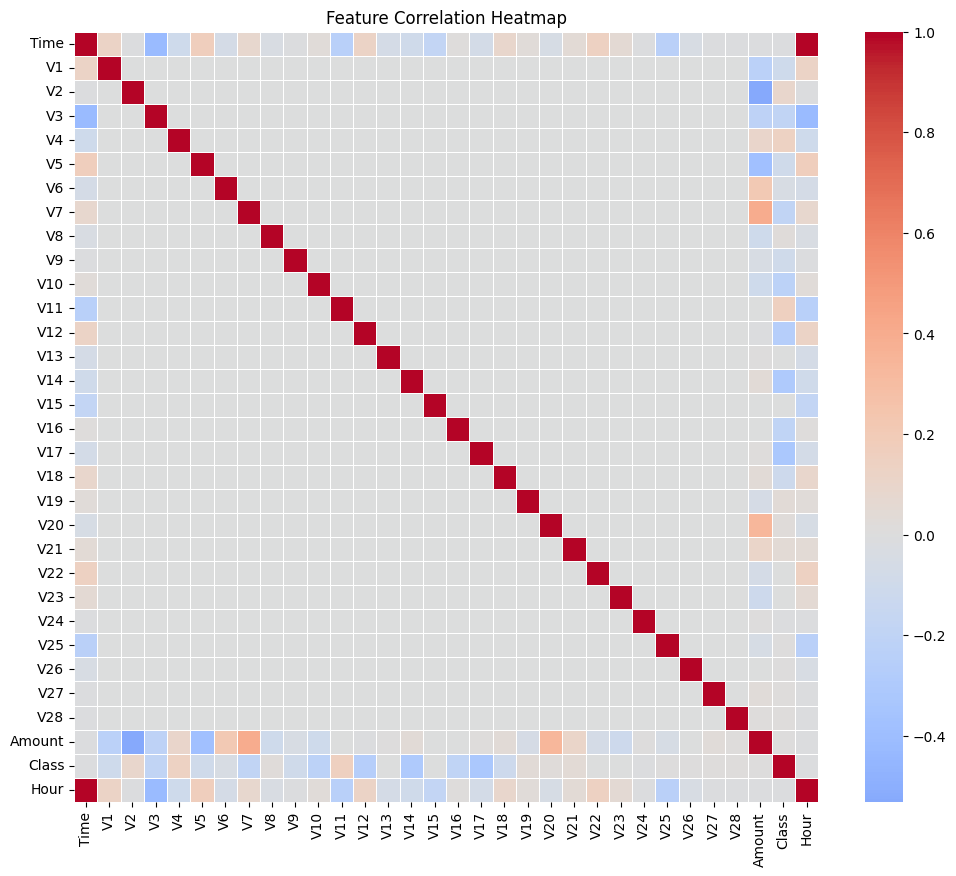

In [ ]:


plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(corr,
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
corr_with_class = df.corr()['Class'].abs().sort_values(ascending=False)
print(corr_with_class.head(20))

Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
V18      0.111485
V1       0.101347
V9       0.097733
V5       0.094974
V2       0.091289
V6       0.043643
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
Name: Class, dtype: float64


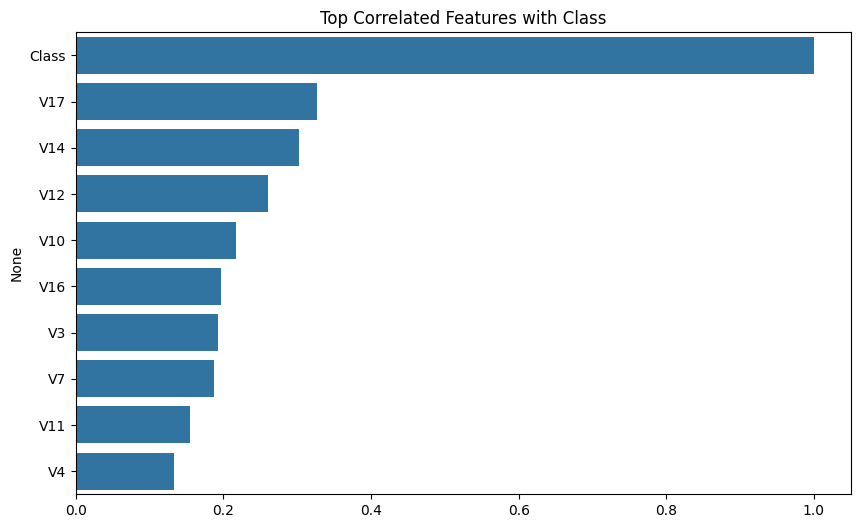

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=corr_with_class.head(10).values,
            y=corr_with_class.head(10).index)
plt.title("Top Correlated Features with Class")
plt.show()

Korelasyon analizi sonucunda bazı featureların dolandırıcılık ile daha güçlü ilişkili olduğu görülmüştür. Ancak bu değişkenlerin anlamları bilinmediğinden, bu analiz yalnızca modelleme sürecine rehberlik etmek amacıyla kullanılmıştır. En yüksek korelasyona sahip özelliklerin model performansına daha fazla katkı sağlaması beklenmektedir.

Özelliklerin hedef değişken (Class) ile olan ilişkisini incelemek amacıyla
korelasyon analizi yapılmıştır. Elde edilen sonuçlara göre, V17, V14, V12, V10, V16 ve V3 değişkenlerinin Class ile en yüksek korelasyona sahip olduğu görülmüştür.

Ancak bu korelasyon değerlerinin mutlak olarak düşük seviyelerde olduğu (≈0.2–0.32 aralığında) dikkat çekmektedir. Bu durum, fraud tespit probleminin doğrusal ilişkilerle kolayca çözülemeyeceğini ve daha karmaşık modelleme tekniklerine ihtiyaç duyulduğunu göstermektedir.

In [ ]:
# Threshold belirle — korelasyonu 0.1'den büyük olanları al
important = corr_with_class[corr_with_class > 0.19].index.tolist()
important.remove('Class')  # kendisini çıkar
print(important)


['V17', 'V14', 'V12', 'V10', 'V16', 'V3']


Bu 6 feature modele en fazla bilgiyi taşıyan değişkenler

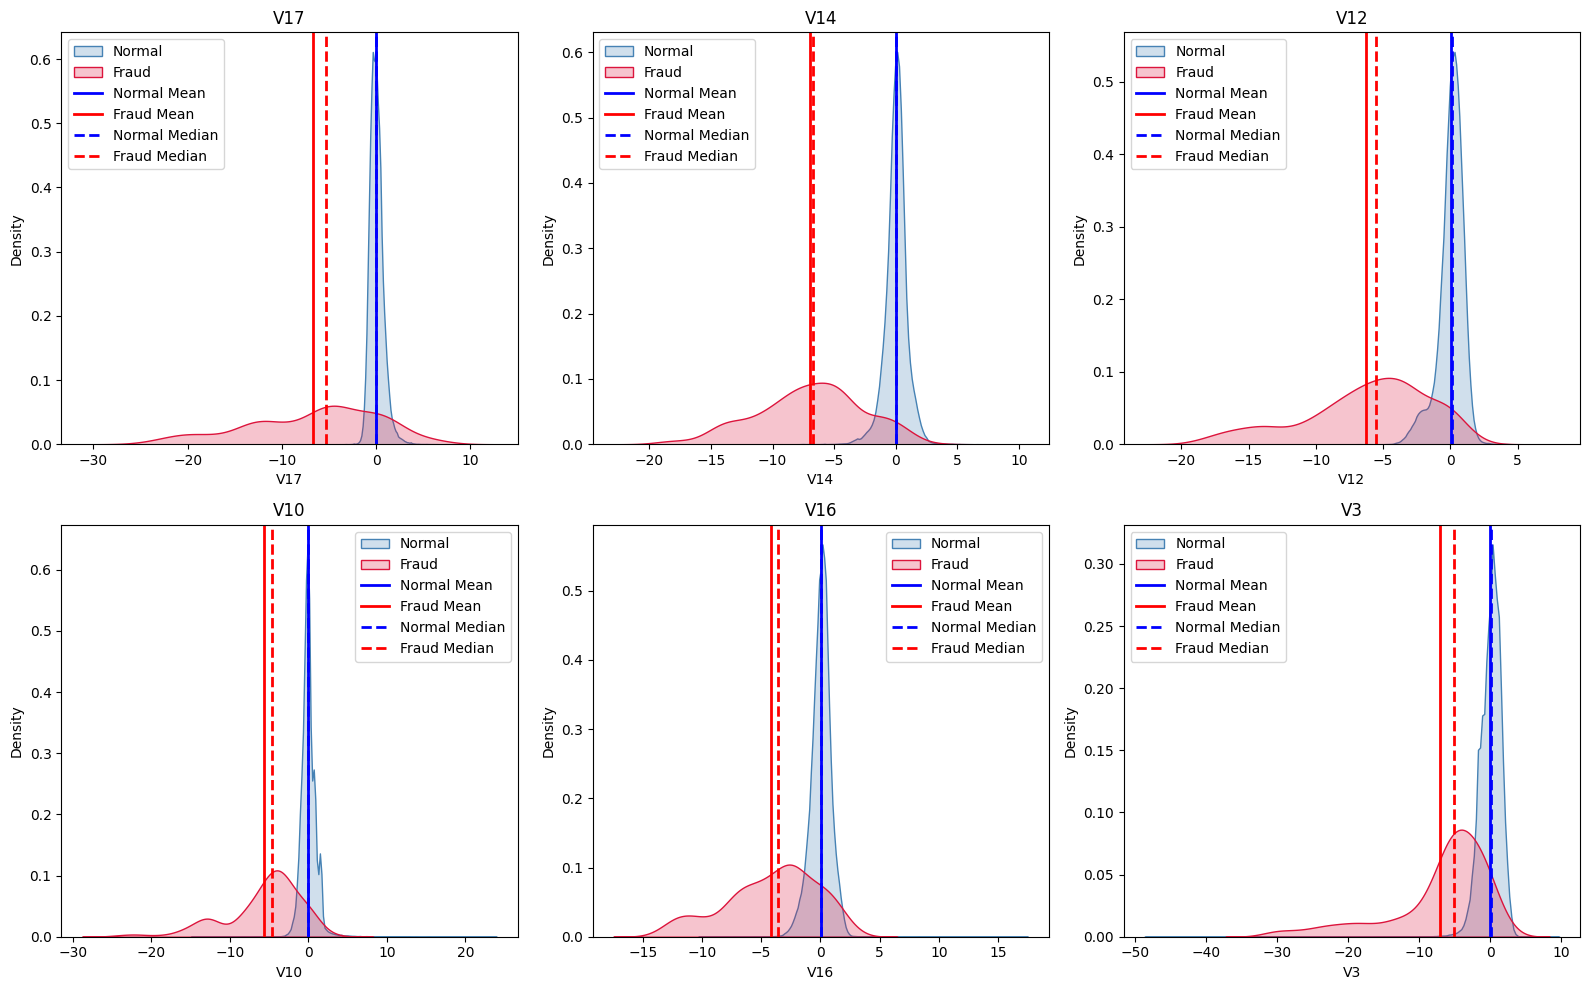

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))

for i, feature in enumerate(important):
    ax = axes[i//3][i%3]

    normal = df[df['Class']==0][feature]
    fraud  = df[df['Class']==1][feature]

    # KDE
    sns.kdeplot(normal,
                label='Normal',
                color='steelblue',
                fill=True,
                ax=ax)

    sns.kdeplot(fraud,
                label='Fraud',
                color='crimson',
                fill=True,
                ax=ax)

    # MEAN (düz çizgi)
    ax.axvline(normal.mean(), color='blue', linestyle='-', linewidth=2, label='Normal Mean')
    ax.axvline(fraud.mean(),  color='red', linestyle='-', linewidth=2, label='Fraud Mean')

    # MEDIAN (kesikli çizgi)
    ax.axvline(normal.median(), color='blue', linestyle='--', linewidth=2, label='Normal Median')
    ax.axvline(fraud.median(),  color='red', linestyle='--', linewidth=2, label='Fraud Median')

    ax.set_title(feature)

    # legend tekrarları azaltmak için
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

KDE grafikleri üzerinde mean ve median değerleri birlikte gösterilerek, hem dağılım hem de merkezi eğilim karşılaştırılmıştır. Mean ve median’ın yakın olması, outlier etkisinin sınırlı olduğunu; sınıflar arasındaki belirgin kayma ise feature’ların ayırt edici olduğunu göstermektedir.

In [ ]:
important = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']
summary = []

for feature in important:
    normal = df[df['Class']==0][feature]
    fraud  = df[df['Class']==1][feature]

    summary.append({
        'Feature': feature,
        'Normal Mean': normal.mean(),
        'Fraud Mean': fraud.mean(),
        'Normal Median': normal.median(),
        'Fraud Median': fraud.median(),
        'Normal Std': normal.std(),
        'Fraud Std': fraud.std()
    })

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values(by='Feature')

print(summary_df)

  Feature  Normal Mean  Fraud Mean  Normal Median  Fraud Median  Normal Std  \
3     V10     0.009824   -5.676883      -0.091872     -4.578825    1.044204   
2     V12     0.010832   -6.259393       0.141679     -5.502530    0.945939   
1     V14     0.012064   -6.971723       0.051947     -6.729720    0.897007   
4     V16     0.007164   -4.139946       0.067377     -3.549795    0.844772   
0     V17     0.011535   -6.665836      -0.064833     -5.302949    0.749457   
5      V3     0.012171   -7.033281       0.182158     -5.075257    1.459429   

   Fraud Std  
3   4.897341  
2   4.654458  
1   4.278940  
4   3.865035  
0   6.970618  
5   7.110937  


In [ ]:
summary_df['Mean Difference'] = abs(summary_df['Fraud Mean'] - summary_df['Normal Mean'])
summary_df['Median Difference'] = abs(summary_df['Fraud Median'] - summary_df['Normal Median'])

print(summary_df[['Feature', 'Mean Difference', 'Median Difference']])

  Feature  Mean Difference  Median Difference
3     V10         5.686707           4.486953
2     V12         6.270225           5.644208
1     V14         6.983787           6.781667
4     V16         4.147110           3.617172
0     V17         6.677371           5.238115
5      V3         7.045452           5.257415


Mean ve median farkları birlikte incelendiğinde, V14, V3, V17 ve V12 feature’larının fraud ve normal sınıflar arasında en belirgin ayrımı sağladığı görülmektedir. Bu feature’larda hem ortalama hem de medyan farklarının yüksek olması, farkın outlier kaynaklı değil, dağılımın genelinden kaynaklandığını göstermektedir.

Seçilen özelliklerin sınıflara göre dağılımı incelendiğinde, fraud ve normal işlemler arasında belirgin bir ayrışma olduğu görülmektedir.

Özellikle V17, V14, V12, V10, V16 ve V3 değişkenlerinde, fraud işlemlerin değerlerinin genel olarak negatif bölgede yoğunlaştığı, normal işlemlerin ise sıfıra yakın değerlerde toplandığı gözlemlenmiştir.

# Veri Ön İşleme, Ölçekleme ve Veri Bölme (Train/Test Split)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

# Önce test setini ayırıyoruz
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Kalan %80 içinden validation ayırıyoruz
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,   # %80'in %25'i = toplam verinin %20'si
    random_state=42,
    stratify=y_temp
)
print(f"Train: %{len(X_train) / len(X) * 100:.0f}")
print(f"Validation: %{len(X_val) / len(X) * 100:.0f}")
print(f"Test: %{len(X_test) / len(X) * 100:.0f}")

Train: %60
Validation: %20
Test: %20


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[['Amount_scaled', 'Hour_scaled']] = scaler.fit_transform(
    X_train[['Amount', 'Hour']]
)

X_val[['Amount_scaled', 'Hour_scaled']] = scaler.transform(
    X_val[['Amount', 'Hour']]
)

X_test[['Amount_scaled', 'Hour_scaled']] = scaler.transform(
    X_test[['Amount', 'Hour']]
)

X_train = X_train.drop(['Amount', 'Hour'], axis=1)
X_val = X_val.drop(['Amount', 'Hour'], axis=1)
X_test = X_test.drop(['Amount', 'Hour'], axis=1)

Eğitim seti modellerin öğrenmesi için kullanılırken, doğrulama seti model seçimi ve performans karşılaştırmaları için kullanılmıştır. Test seti ise model seçim sürecine dahil edilmeden, en son aşamada modelin gerçek performansını değerlendirmek amacıyla kullanılmıştır. Bu yaklaşım, test verisinin model seçimini etkilemesini engelleyerek daha objektif ve güvenilir sonuçlar elde edilmesini sağlar.

# SMOTE Oranı Optimizasyonu ve Model Seçimi (Validation Sonuçları)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (average_precision_score,
                              f1_score, recall_score,
                              precision_score)

sampling_ratios = [0.02, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

results_ratio = {
    'Logistic Regression': [],
    'Random Forest': [],
    'XGBoost': []
}

for ratio in sampling_ratios:
    print(f"\n{'='*50}")
    print(f"SMOTE Ratio: {ratio} | ", end="")

    # SMOTE sadece X_train'e uygula!
    smote = SMOTE(sampling_strategy=ratio, random_state=42)
    X_temp, y_temp = smote.fit_resample(X_train, y_train)

    fraud_count = sum(y_temp == 1)
    print(f"Fraud Sayısı: {fraud_count:,}")
    print(f"{'='*50}")

    models_temp = {
        'Logistic Regression': LogisticRegression(
                                max_iter=10000,
                                random_state=42),
        'Random Forest':       RandomForestClassifier(
                                n_estimators=50,
                                random_state=42,
                                n_jobs=-1),
        'XGBoost':             XGBClassifier(
                                random_state=42,
                                eval_metric='logloss',
                                verbosity=0)
    }

    for name, model in models_temp.items():
        model.fit(X_temp, y_temp)

        # ⭐ Validation seti ile değerlendiriyoruz!
        y_pred_val = model.predict(X_val)
        y_prob_val = model.predict_proba(X_val)[:, 1]

        result = {
            'Ratio':       ratio,
            'Fraud_Count': fraud_count,
            'F1':          round(f1_score(y_val, y_pred_val), 3),
            'Recall':      round(recall_score(y_val, y_pred_val), 3),
            'Precision':   round(precision_score(y_val, y_pred_val), 3),
            'AUPRC':       round(average_precision_score(
                                 y_val, y_prob_val), 3)
        }
        results_ratio[name].append(result)

        print(f"  {name:<25} | "
              f"F1: {result['F1']} | "
              f"AUPRC: {result['AUPRC']} | "
              f"Recall: {result['Recall']}")


SMOTE Ratio: 0.02 | Fraud Sayısı: 3,411
  Logistic Regression       | F1: 0.778 | AUPRC: 0.714 | Recall: 0.778
  Random Forest             | F1: 0.828 | AUPRC: 0.815 | Recall: 0.778
  XGBoost                   | F1: 0.824 | AUPRC: 0.806 | Recall: 0.758

SMOTE Ratio: 0.05 | Fraud Sayısı: 8,529
  Logistic Regression       | F1: 0.755 | AUPRC: 0.695 | Recall: 0.808
  Random Forest             | F1: 0.802 | AUPRC: 0.784 | Recall: 0.758
  XGBoost                   | F1: 0.828 | AUPRC: 0.818 | Recall: 0.778

SMOTE Ratio: 0.1 | Fraud Sayısı: 17,058
  Logistic Regression       | F1: 0.661 | AUPRC: 0.696 | Recall: 0.818
  Random Forest             | F1: 0.834 | AUPRC: 0.791 | Recall: 0.788
  XGBoost                   | F1: 0.822 | AUPRC: 0.81 | Recall: 0.768

SMOTE Ratio: 0.2 | Fraud Sayısı: 34,117
  Logistic Regression       | F1: 0.513 | AUPRC: 0.697 | Recall: 0.818
  Random Forest             | F1: 0.822 | AUPRC: 0.779 | Recall: 0.768
  XGBoost                   | F1: 0.819 | AUPRC: 0.816 |

Farklı SMOTE oranlarının model performansı üzerindeki etkisini inceledim. Veri seti oldukça dengesiz olduğu için fraud sınıfını artırmak amacıyla SMOTE yöntemi kullanılmıştır. Ancak SMOTE işlemi yalnızca eğitim verisine uygulanmıştır. Validation ve test verilerine SMOTE uygulanmamıştır. Böylece modelin gerçek veriye yakın bir dağılım üzerinde değerlendirilmesi sağlanmış ve veri sızıntısı önlenmiştir.

Her SMOTE oranı için eğitim verisi yeniden dengelenmiş, ardından Logistic Regression, Random Forest ve XGBoost modelleri bu yeni eğitim verisiyle eğitilmiştir. Daha sonra modeller validation seti üzerinde test edilmiştir.

Bu aşamada kullanılan temel performans metrikleri F1 skoru, recall, precision ve AUPRC değerleridir. Fraud detection probleminde özellikle recall önemlidir çünkü fraud işlemleri kaçırmak ciddi bir problemdir. Ancak yalnızca recall değerine bakmak yeterli değildir. Bu nedenle F1 ve AUPRC değerleri de birlikte değerlendirilmiştir.

In [ ]:
print("\n" + "="*65)
print("Optimal Ratio — Validation Sonuçları")
print("="*65)

optimal_ratios = {}

for name in results_ratio:
    df_temp = pd.DataFrame(results_ratio[name])
    best_idx = df_temp['AUPRC'].idxmax()
    optimal_ratios[name] = df_temp.loc[best_idx, 'Ratio']

    print(f"\n{name}:")
    print(df_temp.to_string(index=False))
    print(f"→ Optimal Ratio: {optimal_ratios[name]} | "
          f"Best AUPRC: {df_temp.loc[best_idx, 'AUPRC']}")


Optimal Ratio — Validation Sonuçları

Logistic Regression:
 Ratio  Fraud_Count    F1  Recall  Precision  AUPRC
  0.02         3411 0.778   0.778      0.778  0.714
  0.05         8529 0.755   0.808      0.708  0.695
  0.10        17058 0.661   0.818      0.555  0.696
  0.20        34117 0.513   0.818      0.373  0.697
  0.30        51176 0.432   0.838      0.291  0.706
  0.40        68235 0.394   0.838      0.258  0.698
  0.50        85294 0.361   0.838      0.230  0.706
→ Optimal Ratio: 0.02 | Best AUPRC: 0.714

Random Forest:
 Ratio  Fraud_Count    F1  Recall  Precision  AUPRC
  0.02         3411 0.828   0.778      0.885  0.815
  0.05         8529 0.802   0.758      0.852  0.784
  0.10        17058 0.834   0.788      0.886  0.791
  0.20        34117 0.822   0.768      0.884  0.779
  0.30        51176 0.817   0.768      0.874  0.789
  0.40        68235 0.828   0.778      0.885  0.796
  0.50        85294 0.820   0.758      0.893  0.784
→ Optimal Ratio: 0.02 | Best AUPRC: 0.815

XGBoost

Bu çalışma kapsamında, farklı SMOTE oranları altında üç farklı modelin performansı karşılaştırılmıştır. Elde edilen sonuçlara göre XGBoost modeli, hem en yüksek AUPRC değerine ulaşması hem de farklı SMOTE oranlarında stabil performans göstermesi nedeniyle en başarılı model olarak belirlenmiştir.

Random Forest modeli de güçlü ve dengeli sonuçlar üretmiş olsa da, XGBoost modeli sınıflar arasındaki ayrımı daha başarılı gerçekleştirmiştir. Logistic Regression modeli ise özellikle yüksek SMOTE oranlarında precision kaybı yaşayarak zayıf performans göstermiştir.

Sonuç olarak, bu problem için en uygun model XGBoost (SMOTE ratio = 0.05) olarak seçilmiştir.

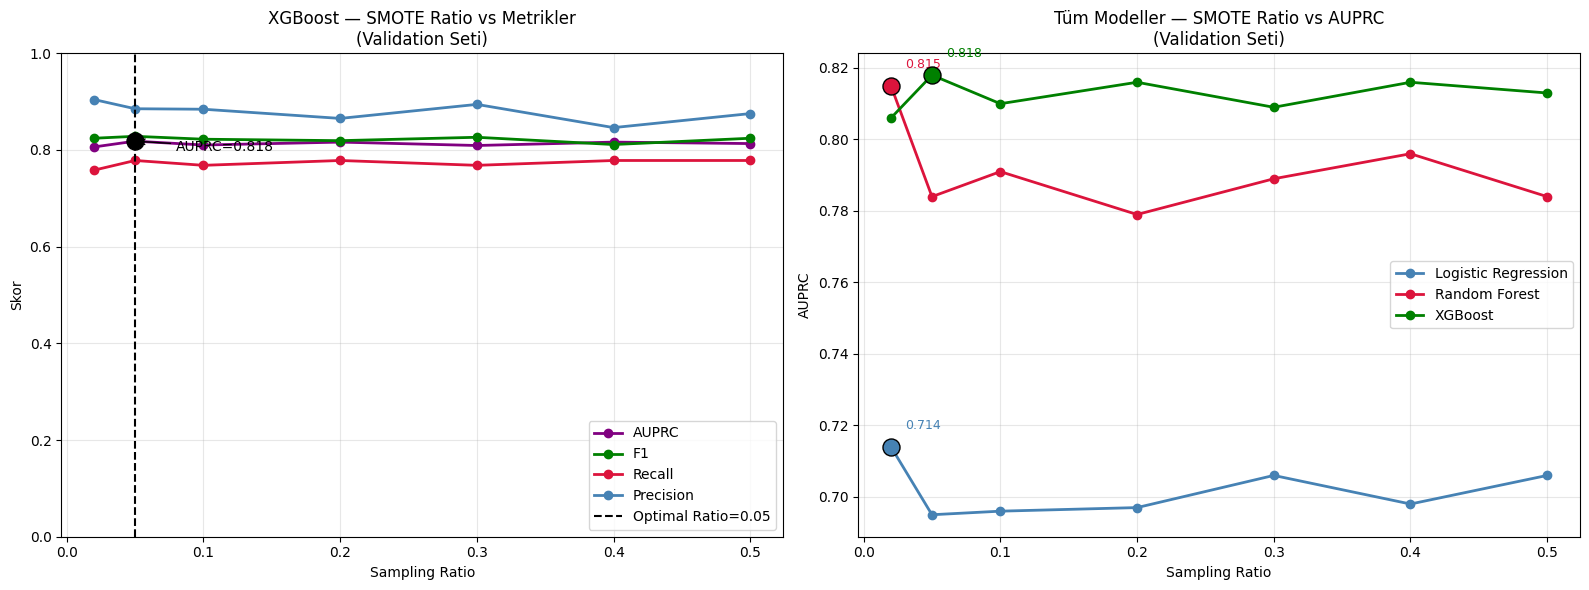

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost sonuçlarını al
xgb_df = pd.DataFrame(results_ratio['XGBoost'])
optimal_ratio = 0.05

# --- Sol Grafik: Tüm Metrikler ---
axes[0].plot(xgb_df['Ratio'], xgb_df['AUPRC'],
             marker='o', color='purple',
             linewidth=2, label='AUPRC')
axes[0].plot(xgb_df['Ratio'], xgb_df['F1'],
             marker='o', color='green',
             linewidth=2, label='F1')
axes[0].plot(xgb_df['Ratio'], xgb_df['Recall'],
             marker='o', color='crimson',
             linewidth=2, label='Recall')
axes[0].plot(xgb_df['Ratio'], xgb_df['Precision'],
             marker='o', color='steelblue',
             linewidth=2, label='Precision')

# Optimal noktayı işaretle
best_auprc = xgb_df.loc[xgb_df['Ratio']==optimal_ratio,
                         'AUPRC'].values[0]
axes[0].axvline(x=optimal_ratio, color='black',
                linestyle='--', linewidth=1.5,
                label=f'Optimal Ratio={optimal_ratio}')
axes[0].scatter([optimal_ratio], [best_auprc],
                color='black', s=150, zorder=5)
axes[0].annotate(f'AUPRC={best_auprc}',
                 xy=(optimal_ratio, best_auprc),
                 xytext=(optimal_ratio+0.03, best_auprc-0.02),
                 fontsize=10,
                 arrowprops=dict(arrowstyle='->'))

axes[0].set_title('XGBoost — SMOTE Ratio vs Metrikler\n'
                  '(Validation Seti)')
axes[0].set_xlabel('Sampling Ratio')
axes[0].set_ylabel('Skor')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1)

# --- Sağ Grafik: 3 Model AUPRC Karşılaştırması ---
colors = {
    'Logistic Regression': 'steelblue',
    'Random Forest':       'crimson',
    'XGBoost':             'green'
}

for name in results_ratio:
    df_temp = pd.DataFrame(results_ratio[name])
    best_ratio = df_temp.loc[df_temp['AUPRC'].idxmax(), 'Ratio']
    best_val   = df_temp['AUPRC'].max()

    axes[1].plot(df_temp['Ratio'], df_temp['AUPRC'],
                 marker='o', color=colors[name],
                 linewidth=2, label=name)

    # Her modelin optimal noktasını işaretle
    axes[1].scatter([best_ratio], [best_val],
                    color=colors[name], s=150,
                    zorder=5, edgecolors='black')
    axes[1].annotate(f'{best_val}',
                     xy=(best_ratio, best_val),
                     xytext=(best_ratio+0.01, best_val+0.005),
                     fontsize=9, color=colors[name])

axes[1].set_title('Tüm Modeller — SMOTE Ratio vs AUPRC\n'
                  '(Validation Seti)')
axes[1].set_xlabel('Sampling Ratio')
axes[1].set_ylabel('AUPRC')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

SMOTE örnekleme oranının model performansına etkisi validation seti üzerinde incelenmiştir. Sol grafikte XGBoost modelinin 0.05 örnekleme oranında en yüksek AUPRC değerine (0.818) ulaştığı görülmektedir. Bu noktanın ötesinde artan sentetik veri miktarının model performansını iyileştirmediği, hatta hafif bir düşüşe yol açtığı gözlemlenmiştir. Bu durum aşırı sentetik veri üretiminin gerçek veri dağılımından uzaklaşmaya ve modelin genelleme kapasitesinin azalmasına neden olduğu şeklinde yorumlanabilir.
Sağ grafikte üç modelin tüm örnekleme oranlarındaki AUPRC karşılaştırması sunulmaktadır. XGBoost tüm oranlar boyunca 0.806-0.818 aralığında stabil bir performans sergileyerek en başarılı model olmuştur. Random Forest başlangıçta rekabetçi bir performans gösterse de (0.815) oran arttıkça dalgalı bir seyir izlemiştir. Lojistik Regresyon ise doğrusal yapısı nedeniyle fraud tespitindeki karmaşık örüntüleri yeterince modelleyememiş ve en düşük AUPRC değerlerini vermiştir. Bu bulgular doğrultusunda XGBoost modeli 0.05 örnekleme oranıyla optimal model olarak seçilmiştir.

# NearMiss Yöntemi Performans Analizi ve Değerlendirmesi (Validation Sonuçları)

In [ ]:
from imblearn.under_sampling import NearMiss
import numpy as np

# Fraud sayısı: 394
# Normal'i kademeli azalt
# sampling_strategy = fraud/normal oranı

sampling_ratios_nm = [0.02, 0.05, 0.10, 0.20,
                      0.30, 0.40, 0.50]

results_ratio_nm = {
    'Logistic Regression': [],
    'Random Forest': [],
    'XGBoost': []
}

for ratio in sampling_ratios_nm:
    print(f"\n{'='*55}")
    print(f"NearMiss Ratio: {ratio} | ", end="")

    # NearMiss uygula — sadece X_train!
    nm = NearMiss(sampling_strategy=ratio)
    X_temp, y_temp = nm.fit_resample(X_train, y_train)

    normal_count = sum(y_temp == 0)
    fraud_count  = sum(y_temp == 1)
    print(f"Normal: {normal_count:,} | Fraud: {fraud_count}")
    print(f"{'='*55}")

    models_temp = {
        'Logistic Regression': LogisticRegression(
                                max_iter=10000,
                                random_state=42),
        'Random Forest':       RandomForestClassifier(
                                n_estimators=50,
                                random_state=42,
                                n_jobs=-1),
        'XGBoost':             XGBClassifier(
                                random_state=42,
                                eval_metric='logloss',
                                verbosity=0)
    }

    for name, model in models_temp.items():
        model.fit(X_temp, y_temp)

        # Validation seti ile değerlendir!
        y_pred_val = model.predict(X_val)
        y_prob_val = model.predict_proba(X_val)[:, 1]

        result = {
            'Ratio':        ratio,
            'Normal_Count': normal_count,
            'Fraud_Count':  fraud_count,
            'F1':           round(f1_score(y_val, y_pred_val), 3),
            'Recall':       round(recall_score(y_val, y_pred_val), 3),
            'Precision':    round(precision_score(y_val, y_pred_val), 3),
            'AUPRC':        round(average_precision_score(
                                  y_val, y_prob_val), 3)
        }
        results_ratio_nm[name].append(result)

        print(f"  {name:<25} | "
              f"F1: {result['F1']} | "
              f"AUPRC: {result['AUPRC']} | "
              f"Recall: {result['Recall']}")


NearMiss Ratio: 0.02 | Normal: 14,750 | Fraud: 295
  Logistic Regression       | F1: 0.744 | AUPRC: 0.678 | Recall: 0.778
  Random Forest             | F1: 0.048 | AUPRC: 0.608 | Recall: 0.828
  XGBoost                   | F1: 0.8 | AUPRC: 0.78 | Recall: 0.808

NearMiss Ratio: 0.05 | Normal: 5,900 | Fraud: 295
  Logistic Regression       | F1: 0.618 | AUPRC: 0.648 | Recall: 0.818
  Random Forest             | F1: 0.051 | AUPRC: 0.709 | Recall: 0.828
  XGBoost                   | F1: 0.635 | AUPRC: 0.802 | Recall: 0.818

NearMiss Ratio: 0.1 | Normal: 2,950 | Fraud: 295
  Logistic Regression       | F1: 0.404 | AUPRC: 0.655 | Recall: 0.828
  Random Forest             | F1: 0.026 | AUPRC: 0.59 | Recall: 0.859
  XGBoost                   | F1: 0.519 | AUPRC: 0.749 | Recall: 0.838

NearMiss Ratio: 0.2 | Normal: 1,475 | Fraud: 295
  Logistic Regression       | F1: 0.264 | AUPRC: 0.652 | Recall: 0.859
  Random Forest             | F1: 0.028 | AUPRC: 0.624 | Recall: 0.848
  XGBoost           

yöntemi uygulanmıştır. Veri seti oldukça dengesiz olduğu için, çoğunluk sınıfını (non-fraud) azaltarak veri dengesini sağlamak hedeflenmiştir. NearMiss yöntemi, çoğunluk sınıfından yalnızca azınlık sınıfına en yakın örnekleri seçerek veri setini dengeler.

Bu işlem yalnızca eğitim verisine uygulanmıştır. Validation ve test verilerine herhangi bir yeniden örnekleme yapılmamıştır. Böylece modelin gerçek veri dağılımına benzer bir yapı üzerinde değerlendirilmesi sağlanmış ve veri sızıntısı önlenmiştir.

Logistic Regression, Random Forest ve XGBoost modelleri bu veri ile eğitilmiştir. Eğitilen modeller, validation seti üzerinde test edilerek performansları karşılaştırılmıştır.

In [ ]:
print("\n" + "="*65)
print("NearMiss Ratio Optimization — Validation Sonuçları")
print("="*65)

optimal_ratios_nm = {}

for name in results_ratio_nm:
    df_temp = pd.DataFrame(results_ratio_nm[name])
    best_idx   = df_temp['AUPRC'].idxmax()
    best_ratio = df_temp.loc[best_idx, 'Ratio']
    best_auprc = df_temp.loc[best_idx, 'AUPRC']
    optimal_ratios_nm[name] = best_ratio

    print(f"\n{name}:")
    print(df_temp[['Ratio', 'Normal_Count', 'Fraud_Count',
                   'F1', 'Recall', 'Precision',
                   'AUPRC']].to_string(index=False))
    print(f"→ Optimal Ratio: {best_ratio} | "
          f"Best AUPRC: {best_auprc}")


NearMiss Ratio Optimization — Validation Sonuçları

Logistic Regression:
 Ratio  Normal_Count  Fraud_Count    F1  Recall  Precision  AUPRC
  0.02         14750          295 0.744   0.778      0.713  0.678
  0.05          5900          295 0.618   0.818      0.497  0.648
  0.10          2950          295 0.404   0.828      0.267  0.655
  0.20          1475          295 0.264   0.859      0.156  0.652
  0.30           983          295 0.193   0.879      0.108  0.659
  0.40           737          295 0.160   0.879      0.088  0.651
  0.50           590          295 0.147   0.879      0.080  0.647
→ Optimal Ratio: 0.02 | Best AUPRC: 0.678

Random Forest:
 Ratio  Normal_Count  Fraud_Count    F1  Recall  Precision  AUPRC
  0.02         14750          295 0.048   0.828      0.025  0.608
  0.05          5900          295 0.051   0.828      0.026  0.709
  0.10          2950          295 0.026   0.859      0.013  0.590
  0.20          1475          295 0.028   0.848      0.014  0.624
  0.30    

NearMiss yöntemi ile yapılan deneyler sonucunda, çoğunluk sınıfının azaltılmasının model performansını olumsuz etkilediği gözlemlenmiştir. Özellikle precision değerlerinde ciddi düşüşler meydana gelmiş ve bu durum F1 skorunun önemli ölçüde azalmasına neden olmuştur.

Random Forest ve Logistic Regression modelleri NearMiss ile oldukça zayıf performans gösterirken, XGBoost modeli yalnızca düşük oranlarda kabul edilebilir sonuçlar üretmiştir. Ancak genel olarak veri kaybı nedeniyle model performansında istikrarsızlık gözlemlenmiştir.

SMOTE yöntemi ile karşılaştırıldığında, NearMiss yaklaşımının bu problem için uygun olmadığı açıkça görülmektedir. Bu nedenle model geliştirme sürecinde oversampling tabanlı yöntemlerin tercih edilmesi daha doğru bir yaklaşım olacaktır.

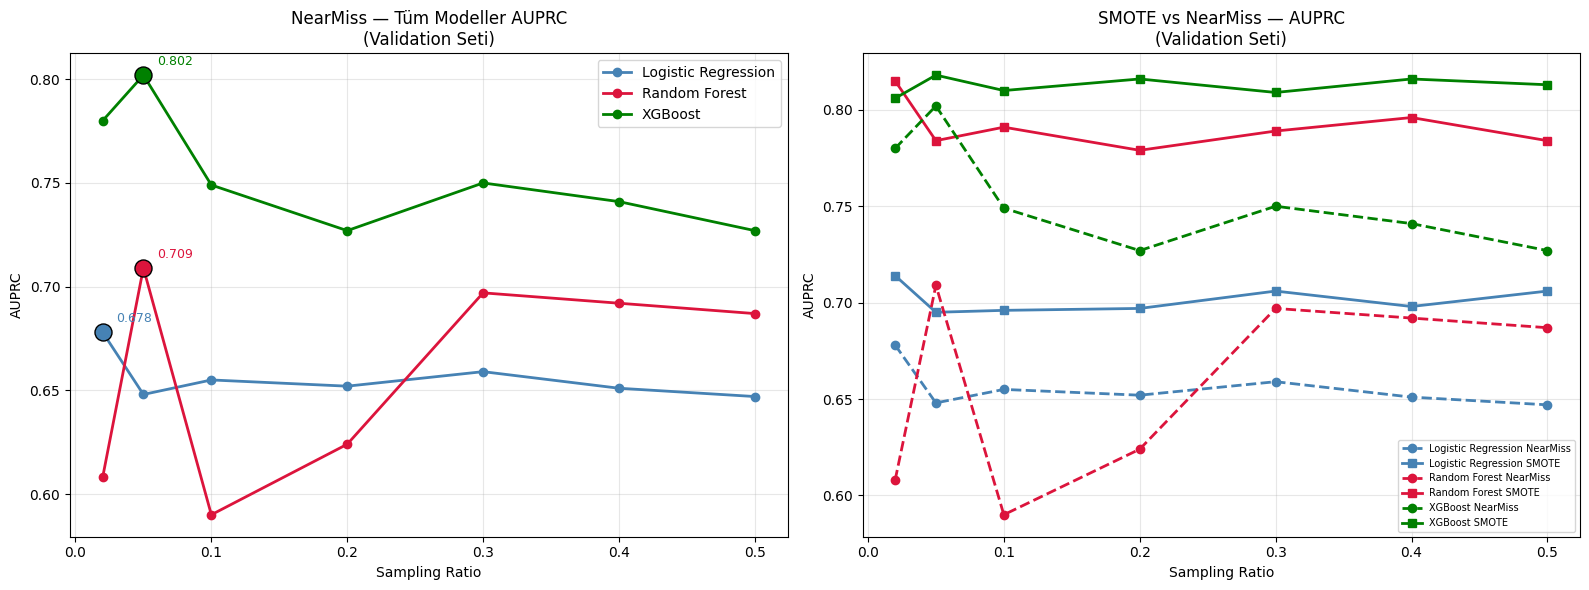

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {
    'Logistic Regression': 'steelblue',
    'Random Forest':       'crimson',
    'XGBoost':             'green'
}

# Sol: 3 Model AUPRC Karşılaştırması
for name in results_ratio_nm:
    df_temp    = pd.DataFrame(results_ratio_nm[name])
    best_ratio = optimal_ratios_nm[name]
    best_val   = df_temp['AUPRC'].max()

    axes[0].plot(df_temp['Ratio'], df_temp['AUPRC'],
                 marker='o', color=colors[name],
                 linewidth=2, label=name)
    axes[0].scatter([best_ratio], [best_val],
                    color=colors[name], s=150,
                    zorder=5, edgecolors='black')
    axes[0].annotate(f'{best_val}',
                     xy=(best_ratio, best_val),
                     xytext=(best_ratio+0.01, best_val+0.005),
                     fontsize=9, color=colors[name])

axes[0].set_title('NearMiss — Tüm Modeller AUPRC\n'
                  '(Validation Seti)')
axes[0].set_xlabel('Sampling Ratio')
axes[0].set_ylabel('AUPRC')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Sağ: SMOTE vs NearMiss AUPRC Karşılaştırması
for name in results_ratio_nm:
    df_nm   = pd.DataFrame(results_ratio_nm[name])
    df_smote = pd.DataFrame(results_ratio[name])

    axes[1].plot(df_nm['Ratio'], df_nm['AUPRC'],
                 marker='o', color=colors[name],
                 linewidth=2, linestyle='--',
                 label=f'{name} NearMiss')
    axes[1].plot(df_smote['Ratio'], df_smote['AUPRC'],
                 marker='s', color=colors[name],
                 linewidth=2, linestyle='-',
                 label=f'{name} SMOTE')

axes[1].set_title('SMOTE vs NearMiss — AUPRC\n'
                  '(Validation Seti)')
axes[1].set_xlabel('Sampling Ratio')
axes[1].set_ylabel('AUPRC')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

NearMiss örnekleme oranı optimizasyonunda en iyi sonuç XGBoost modeliyle 0.05 oranında elde edilmiş ve validation AUPRC değeri 0.802 olarak hesaplanmıştır. Ancak tüm modellerde SMOTE ile kıyaslandığında NearMiss'in belirgin biçimde daha düşük performans sergilediği görülmektedir. Bunun temel nedeni NearMiss'in normal işlem örneklerini eleyerek modelin öğrenebileceği veri miktarını ciddi ölçüde azaltmasıdır. Random Forest modelinde bu etki en belirgin şekilde gözlemlenmiş, F1 skoru 0.05'in altında kalmıştır. Bu bulgular fraud tespiti gibi dengesiz sınıf problemlerinde veri silme yerine sentetik veri üretiminin daha etkili bir strateji olduğunu doğrulamaktadır

# Validation Sonuçlarına Göre Model Karşılaştırması ve Nihai Model Seçimi

In [ ]:
final_comparison = pd.DataFrame({
    'Model': [
        'LR + NearMiss (val)',
        'LR + SMOTE (val)',
        'RF + NearMiss (val)',
        'RF + SMOTE (val)',
        'XGB + NearMiss (val)',
        'XGB + SMOTE (val)'
    ],
    'AUPRC': [
        max(r['AUPRC'] for r in results_ratio_nm['Logistic Regression']),
        max(r['AUPRC'] for r in results_ratio['Logistic Regression']),
        max(r['AUPRC'] for r in results_ratio_nm['Random Forest']),
        max(r['AUPRC'] for r in results_ratio['Random Forest']),
        max(r['AUPRC'] for r in results_ratio_nm['XGBoost']),
        max(r['AUPRC'] for r in results_ratio['XGBoost'])
    ],
    'Recall': [
        max(r['Recall'] for r in results_ratio_nm['Logistic Regression']),
        max(r['Recall'] for r in results_ratio['Logistic Regression']),
        max(r['Recall'] for r in results_ratio_nm['Random Forest']),
        max(r['Recall'] for r in results_ratio['Random Forest']),
        max(r['Recall'] for r in results_ratio_nm['XGBoost']),
        max(r['Recall'] for r in results_ratio['XGBoost'])
    ],
    'F1': [
        max(r['F1'] for r in results_ratio_nm['Logistic Regression']),
        max(r['F1'] for r in results_ratio['Logistic Regression']),
        max(r['F1'] for r in results_ratio_nm['Random Forest']),
        max(r['F1'] for r in results_ratio['Random Forest']),
        max(r['F1'] for r in results_ratio_nm['XGBoost']),
        max(r['F1'] for r in results_ratio['XGBoost'])
    ],
    'Precision': [
        max(r['Precision'] for r in results_ratio_nm['Logistic Regression']),
        max(r['Precision'] for r in results_ratio['Logistic Regression']),
        max(r['Precision'] for r in results_ratio_nm['Random Forest']),
        max(r['Precision'] for r in results_ratio['Random Forest']),
        max(r['Precision'] for r in results_ratio_nm['XGBoost']),
        max(r['Precision'] for r in results_ratio['XGBoost'])
    ]
})

final_comparison = final_comparison.round(3)

best_idx = final_comparison['AUPRC'].idxmax()
final_comparison['Kazanan'] = ''
final_comparison.loc[best_idx, 'Kazanan'] = '🏆'

print(final_comparison.to_string(index=False))

               Model  AUPRC  Recall    F1  Precision Kazanan
 LR + NearMiss (val)  0.678   0.879 0.744      0.713        
    LR + SMOTE (val)  0.714   0.838 0.778      0.778        
 RF + NearMiss (val)  0.709   0.859 0.051      0.026        
    RF + SMOTE (val)  0.815   0.788 0.834      0.893        
XGB + NearMiss (val)  0.802   0.879 0.800      0.792        
   XGB + SMOTE (val)  0.818   0.778 0.828      0.904       🏆


Bu çalışma kapsamında farklı veri dengeleme yöntemleri ve makine öğrenmesi modelleri karşılaştırılmıştır. Elde edilen sonuçlara göre SMOTE yöntemi, NearMiss yöntemine kıyasla belirgin şekilde daha başarılı performans göstermiştir. Özellikle NearMiss yönteminde veri kaybı nedeniyle model performansında ciddi düşüşler gözlemlenmiştir.

Model bazında değerlendirildiğinde, ağaç tabanlı yöntemlerin (Random Forest ve XGBoost) lineer modellere göre daha başarılı olduğu görülmüştür. En yüksek AUPRC değerine sahip olan XGBoost + SMOTE modeli, hem yüksek precision hem de dengeli recall değerleri ile en iyi performansı göstermiştir.

Sonuç olarak, bu problem için en uygun yaklaşımın SMOTE ile dengelenmiş veri üzerinde eğitilmiş XGBoost modeli olduğu belirlenmiştir.

# Final Modelinin (XGBoost) Performans Analizi

In [ ]:
# Optimal ratio ile SMOTE
smote_final = SMOTE(sampling_strategy=0.05, random_state=42)
X_final, y_final = smote_final.fit_resample(X_train, y_train)

print("=== Final SMOTE Sonuçları ===")
print(f"Normal: {sum(y_final==0):,}")
print(f"Fraud:  {sum(y_final==1):,}")
print(f"Oran:   1 fraud / {sum(y_final==0)//sum(y_final==1)} normal")

=== Final SMOTE Sonuçları ===
Normal: 170,588
Fraud:  8,529
Oran:   1 fraud / 20 normal


Bu oran, daha önce validation sonuçlarında en iyi performansı veren SMOTE ratio = 0.05 değerine karşılık gelmektedir. Yani fraud sınıfı tamamen çoğunluk sınıfına eşitlenmemiştir. Bunun yerine daha kontrollü bir oversampling uygulanmıştır.

In [ ]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# Sadece train verisiyle eğit!
final_model.fit(
    X_final, y_final,
    eval_set=[(X_val, y_val)],   # validation izle
    verbose=False
)

print("Final model eğitildi ✅")

Final model eğitildi ✅


Model eğitiminde yalnızca train verisi kullanılmış, validation verisi ise sadece modelin eğitim sürecini izlemek için verilmiştir.

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score
y_pred_val = final_model.predict(X_val)
y_prob_val = final_model.predict_proba(X_val)[:, 1]

print("=== Validation Sonucu (Son Kontrol) ===")
print(classification_report(y_val, y_pred_val,
      target_names=['Normal', 'Fraud']))
print(f"AUPRC:   {average_precision_score(y_val, y_prob_val):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_val):.3f}")

=== Validation Sonucu (Son Kontrol) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56863
       Fraud       0.89      0.78      0.83        99

    accuracy                           1.00     56962
   macro avg       0.94      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962

AUPRC:   0.818
ROC-AUC: 0.967


In [ ]:
# ⭐ Test seti sadece burada kullanılıyor!
y_pred_test = final_model.predict(X_test)
y_prob_test = final_model.predict_proba(X_test)[:, 1]

print("=== FINAL — Test Sonuçları ===")
print(classification_report(y_test, y_pred_test,
      target_names=['Normal', 'Fraud']))
print(f"AUPRC:   {average_precision_score(y_test, y_prob_test):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_test):.3f}")

=== FINAL — Test Sonuçları ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUPRC:   0.866
ROC-AUC: 0.978


In [ ]:
print("\n=== Validation vs Test Karşılaştırması ===")
print(f"{'Metrik':<12} {'Validation':>12} {'Test':>12}")
print("-" * 38)

val_auprc  = average_precision_score(y_val,
             final_model.predict_proba(X_val)[:, 1])
test_auprc = average_precision_score(y_test, y_prob_test)

val_roc  = roc_auc_score(y_val,
           final_model.predict_proba(X_val)[:, 1])
test_roc = roc_auc_score(y_test, y_prob_test)

print(f"{'AUPRC':<12} {val_auprc:>12.3f} {test_auprc:>12.3f}")
print(f"{'ROC-AUC':<12} {val_roc:>12.3f} {test_roc:>12.3f}")


=== Validation vs Test Karşılaştırması ===
Metrik         Validation         Test
--------------------------------------
AUPRC               0.818        0.866
ROC-AUC             0.967        0.978


Final model, test seti üzerinde yüksek performans göstermiştir. Fraud sınıfı için elde edilen precision ve recall değerleri, modelin hem doğru tahmin yapma hem de önemli örnekleri kaçırmama açısından dengeli bir performans sergilediğini göstermektedir.

AUPRC değerinin validation setine kıyasla test setinde daha yüksek olması, modelin overfitting yapmadığını ve genelleme yeteneğinin güçlü olduğunu göstermektedir. Benzer şekilde ROC-AUC değerinin yüksek olması, modelin sınıflar arasındaki ayrımı başarılı bir şekilde gerçekleştirdiğini ortaya koymaktadır.

Sonuç olarak, XGBoost + SMOTE yaklaşımı, hem validation hem de test sonuçlarına göre bu problem için güvenilir ve yüksek performanslı bir çözüm sunmaktadır.

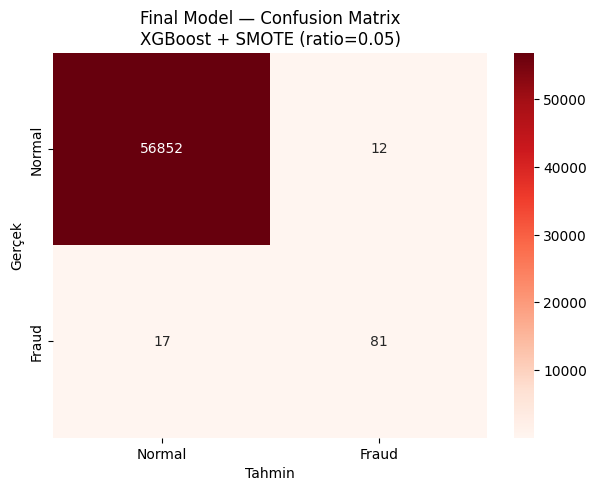


Doğru tespit edilen fraud (TP):     81
Kaçırılan fraud (FN):               17
Yanlış alarm (FP):                  12
Doğru normal (TN):                  56,852

Yakalanan fraud oranı:  %82.7
Yanlış alarm oranı:     %0.02


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Final Model — Confusion Matrix\n'
          'XGBoost + SMOTE (ratio=0.05)')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.show()

# Detaylı hata analizi
tn, fp, fn, tp = cm.ravel()
print(f"\nDoğru tespit edilen fraud (TP):     {tp}")
print(f"Kaçırılan fraud (FN):               {fn}")
print(f"Yanlış alarm (FP):                  {fp}")
print(f"Doğru normal (TN):                  {tn:,}")
print(f"\nYakalanan fraud oranı:  %{tp/(tp+fn)*100:.1f}")
print(f"Yanlış alarm oranı:     %{fp/(fp+tn)*100:.2f}")

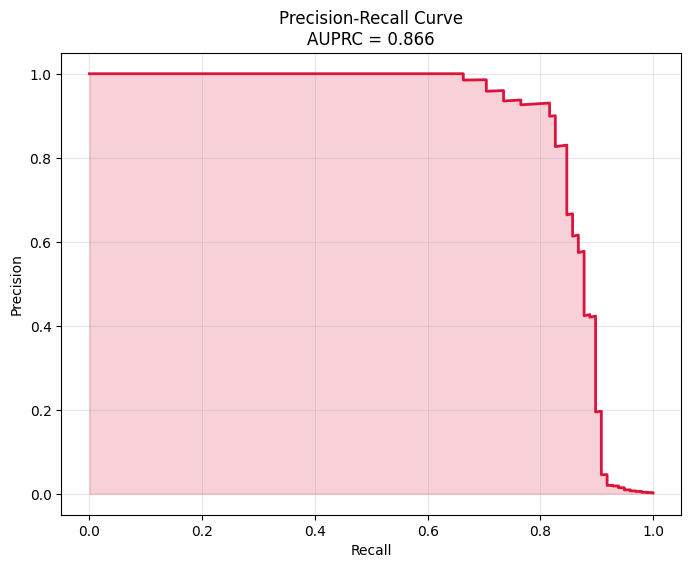

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

precisions, recalls, _ = precision_recall_curve(
    y_test, y_prob_test
)
auprc = auc(recalls, precisions)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='crimson', linewidth=2)
plt.fill_between(recalls, precisions,
                 alpha=0.2, color='crimson')
plt.title(f'Precision-Recall Curve\nAUPRC = {auprc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(alpha=0.3)
plt.show()

Precision-Recall eğrisi incelendiğinde modelin geniş bir recall aralığında yüksek precision değerlerini koruyabildiği görülmektedir. Özellikle orta recall seviyelerinde precision değerinin yüksek kalması, modelin daha fazla fraud işlemi tespit ederken yanlış alarm oranını düşük tuttuğunu göstermektedir.

Recall değeri 1’e yaklaştıkça precision değerinde düşüş gözlemlenmiştir. Bu durum, modelin daha fazla fraud yakalamak için daha agresif tahminler yapmasından kaynaklanmaktadır ve beklenen bir davranıştır.

Elde edilen AUPRC değerinin yüksek olması, modelin dengesiz veri setlerinde başarılı bir şekilde performans gösterdiğini ortaya koymaktadır.

Validation seti üzerinde en yüksek AUPRC skorunu elde eden XGBoost modeli optimal SMOTE ratio'su 0.05 ile eğitilmiştir. Bu oran fraud sayısını 394'ten 8.529'a çıkarmış, 227.476'ya çıkarmak yerine az ama kaliteli sentetik veri üretilmiştir. Test seti yalnızca bu final aşamada kullanılmış olup elde edilen sonuçlar modelin gerçek dünya performansını yansıtmaktadır.

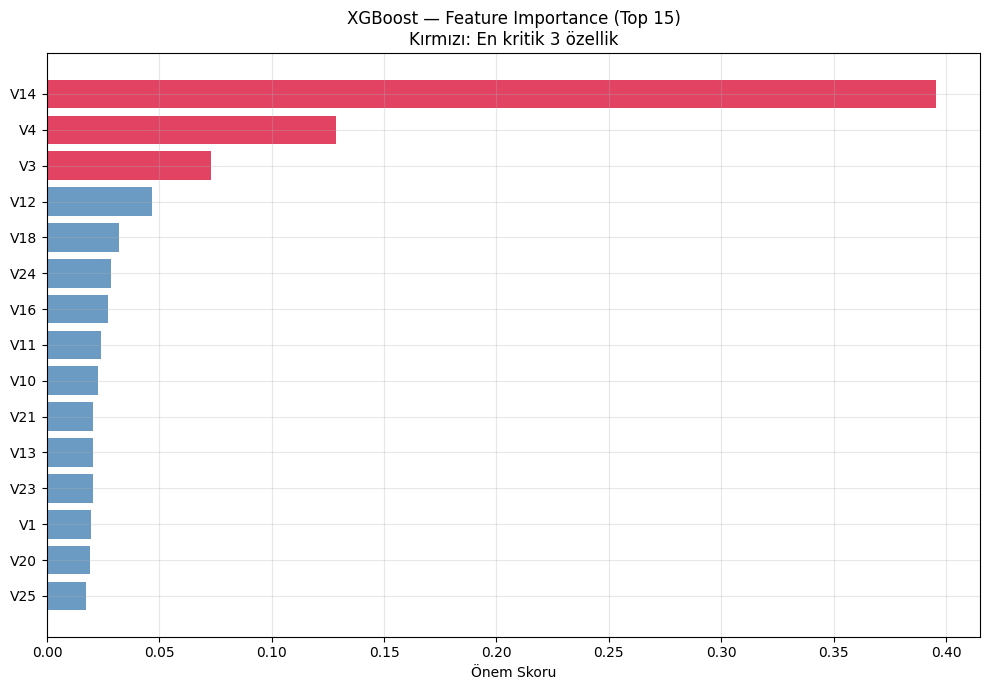

Feature  Importance
    V14    0.395361
     V4    0.128469
     V3    0.073079
    V12    0.046841
    V18    0.032208
    V24    0.028386
    V16    0.027126
    V11    0.023991
    V10    0.022861
    V21    0.020565
    V13    0.020417
    V23    0.020389
     V1    0.019637
    V20    0.019219
    V25    0.017405


In [ ]:
feat_imp = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': final_model_loss.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
colors = ['crimson' if i < 3 else 'steelblue'
          for i in range(len(feat_imp))]
plt.barh(feat_imp['Feature'],
         feat_imp['Importance'],
         color=colors, alpha=0.8)
plt.title('XGBoost — Feature Importance (Top 15)\n'
          'Kırmızı: En kritik 3 özellik')
plt.xlabel('Önem Skoru')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(feat_imp.to_string(index=False))

Bu analizde, modelin karar mekanizmasını daha iyi anlamak amacıyla XGBoost modeline ait feature importance değerleri incelenmiştir. Elde edilen sonuçlara göre modelin kararlarını belirlemede belirli değişkenlerin diğerlerine kıyasla çok daha baskın rol oynadığı görülmektedir.

Özellikle en yüksek önem skoruna sahip ilk birkaç özellik, modelin fraud ve normal işlemleri ayırt etmesinde kritik rol oynamaktadır. Bu durum, veri setinde bazı değişkenlerin sınıflar arasında daha ayırt edici olduğunu göstermektedir. Modelin bu özelliklere daha fazla ağırlık vermesi, karar sınırını bu değişkenler üzerinden şekillendirdiğini göstermektedir.

# XGBoost’ta Loss Ağırlıklandırma Analizi ve Model Karşılaştırması

In [ ]:
# Orijinal train verisindeki oranı kullan
# (SMOTE öncesi — gerçek dengesizliği yansıtır)
scale = sum(y_train==0) / sum(y_train==1)
print(f"Normal sayısı:  {sum(y_train==0):,}")
print(f"Fraud sayısı:   {sum(y_train==1):,}")
print(f"Scale pos weight: {scale:.1f}")

Normal sayısı:  170,588
Fraud sayısı:   295
Scale pos weight: 578.3


In [ ]:
# SMOTE veri hazır — ratio=0.05
# X_final, y_final zaten elimizde ✅

final_model_loss = XGBClassifier(
    n_estimators=500,          # daha fazla iterasyon
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale,    # ← loss ağırlığı!
    early_stopping_rounds=20,  # ← loss artarsa dur!
    verbosity=0
)

final_model_loss.fit(
    X_final, y_final,
    eval_set=[(X_val, y_val)],  # validation ile izle
    verbose=True                 # loss'u göster
)

print(f"\nEn iyi iterasyon: "
      f"{final_model_loss.best_iteration}")

[0]	validation_0-logloss:0.68237
[1]	validation_0-logloss:0.47018
[2]	validation_0-logloss:0.35390
[3]	validation_0-logloss:0.27188
[4]	validation_0-logloss:0.21426
[5]	validation_0-logloss:0.16859
[6]	validation_0-logloss:0.13751
[7]	validation_0-logloss:0.11320
[8]	validation_0-logloss:0.09264
[9]	validation_0-logloss:0.07735
[10]	validation_0-logloss:0.06490
[11]	validation_0-logloss:0.05715
[12]	validation_0-logloss:0.04931
[13]	validation_0-logloss:0.04329
[14]	validation_0-logloss:0.03849
[15]	validation_0-logloss:0.03512
[16]	validation_0-logloss:0.03107
[17]	validation_0-logloss:0.02813
[18]	validation_0-logloss:0.02597
[19]	validation_0-logloss:0.02403
[20]	validation_0-logloss:0.02234
[21]	validation_0-logloss:0.02048
[22]	validation_0-logloss:0.01871
[23]	validation_0-logloss:0.01738
[24]	validation_0-logloss:0.01623
[25]	validation_0-logloss:0.01481
[26]	validation_0-logloss:0.01376
[27]	validation_0-logloss:0.01292
[28]	validation_0-logloss:0.01198
[29]	validation_0-loglos

Bu bölümde XGBoost modelinin performansını artırmak amacıyla sınıf ağırlıklandırma yöntemi uygulanmıştır. Orijinal eğitim verisindeki sınıf dağılımı dikkate alınarak scale_pos_weight parametresi hesaplanmış ve modelin loss fonksiyonu fraud sınıfına daha duyarlı hale getirilmiştir.

Bu parametre, fraud sınıfının yanlış sınıflandırılması durumunda daha yüksek bir ceza uygulanmasını sağlayarak modelin bu sınıfa daha fazla odaklanmasına yardımcı olmaktadır.

Ayrıca bu yaklaşım, SMOTE ile birlikte kullanılarak hem veri seviyesinde hem de model seviyesinde bir dengeleme stratejisi oluşturulmuştur. Model, validation seti kullanılarak izlenmiş ve early stopping mekanizması sayesinde overfitting önlenmiştir.

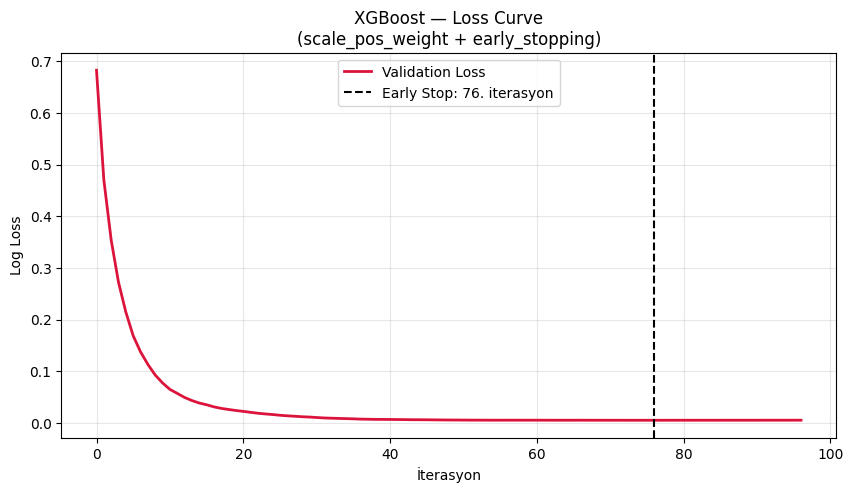

In [ ]:
results_loss = final_model_loss.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results_loss['validation_0']['logloss'],
         color='crimson', linewidth=2,
         label='Validation Loss')
plt.axvline(x=final_model_loss.best_iteration,
            color='black', linestyle='--',
            label=f'Early Stop: '
                  f'{final_model_loss.best_iteration}. iterasyon')
plt.title('XGBoost — Loss Curve\n'
          '(scale_pos_weight + early_stopping)')
plt.xlabel('İterasyon')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

XGBoost modelinin eğitim süreci incelendiğinde, log loss değerinin ilk iterasyonlarda hızlı bir şekilde düştüğü ve modelin veri yapısını kısa sürede öğrendiği gözlemlenmiştir. İlerleyen iterasyonlarda loss değerindeki azalma yavaşlamış ve belirli bir noktadan sonra stabil hale gelmiştir.

Validation loss’un yaklaşık 76. iterasyonda iyileşmeyi durdurması üzerine early stopping mekanizması devreye girerek eğitim süreci sonlandırılmıştır. Bu durum, modelin gereksiz yere daha fazla öğrenerek overfitting yapmasının önüne geçmiştir.

Genel olarak loss eğrisi, modelin dengeli bir şekilde öğrenme gerçekleştirdiğini ve seçilen hiperparametrelerin uygun olduğunu göstermektedir.

In [ ]:
y_pred_loss = final_model_loss.predict(X_test)
y_prob_loss = final_model_loss.predict_proba(X_test)[:, 1]

print("=== Loss Fonksiyonlu Model — Test Sonuçları ===")
print(classification_report(y_test, y_pred_loss,
      target_names=['Normal', 'Fraud']))
print(f"AUPRC:   {average_precision_score(y_test, y_prob_loss):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_loss):.3f}")

# Önceki model ile karşılaştır
print("\n=== Loss'suz vs Loss'lu Karşılaştırma ===")
print(f"{'Metrik':<12} {'Loss\'suz':>12} {'Loss\'lu':>12}")
print("-" * 38)

metrics = {
    'AUPRC':   [average_precision_score(y_test, y_prob_test),
                average_precision_score(y_test, y_prob_loss)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_test),
                roc_auc_score(y_test, y_prob_loss)],
    'F1':      [f1_score(y_test, y_pred_test),
                f1_score(y_test, y_pred_loss)],
    'Recall':  [recall_score(y_test, y_pred_test),
                recall_score(y_test, y_pred_loss)],
    'Precision':[precision_score(y_test, y_pred_test),
                 precision_score(y_test, y_pred_loss)]
}

for name, vals in metrics.items():
    kazanan = '⬆️' if vals[1] > vals[0] else '⬇️'
    print(f"{name:<12} {vals[0]:>12.3f} "
          f"{vals[1]:>12.3f} {kazanan}")

=== Loss Fonksiyonlu Model — Test Sonuçları ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.77      0.88      0.82        98

    accuracy                           1.00     56962
   macro avg       0.88      0.94      0.91     56962
weighted avg       1.00      1.00      1.00     56962

AUPRC:   0.872
ROC-AUC: 0.969

=== Loss'suz vs Loss'lu Karşılaştırma ===
Metrik           Loss'suz      Loss'lu
--------------------------------------
AUPRC               0.866        0.872 ⬆️
ROC-AUC             0.978        0.969 ⬇️
F1                  0.848        0.819 ⬇️
Recall              0.827        0.878 ⬆️
Precision           0.871        0.768 ⬇️


Bu karşılaştırma, SMOTE ile dengelenmiş veri üzerinde XGBoost modeline ek olarak sınıf ağırlıklandırma uygulanmasının performans üzerindeki etkisini incelemek amacıyla yapılmıştır.

Elde edilen sonuçlar, veri seviyesinde dengeleme (SMOTE) ile model seviyesinde dengelemenin (scale_pos_weight) birlikte kullanımının performansı nasıl etkilediğini göstermektedir.

Loss fonksiyonuna sınıf ağırlığı eklenmesiyle modelin fraud sınıfına daha duyarlı hale geldiği gözlemlenmiştir. Bu durum recall değerinde artış sağlamış, yani model daha fazla fraud işlemi doğru şekilde tespit edebilmiştir.

Ancak bu iyileşme, precision değerinde düşüşe neden olmuş ve modelin daha fazla yanlış alarm üretmesine yol açmıştır. Buna bağlı olarak F1 skorunda da hafif bir düşüş gözlemlenmiştir.

Bu sonuçlar, modelin daha agresif bir tahmin stratejisi benimsediğini göstermektedir. Fraud detection problemlerinde önemli olan fraud işlemlerinin kaçırılmaması olduğundan, recall artışı kritik bir avantaj olarak değerlendirilebilir. Bu nedenle loss ağırlıklı model, uygulama senaryosuna bağlı olarak tercih edilebilir.

# Genel Değerlendirme, Bulgular ve Sonuç

Çalışmanın Amacı:

Bu çalışmada 284.807 kredi kartı işleminden oluşan ve
yalnızca %0.17'si dolandırıcılık (fraud) içeren aşırı
dengesiz bir veri seti üzerinde makine öğrenmesi tabanlı
bir fraud tespit sistemi geliştirilmiştir. Çalışmanın
temel hedefi, sınıf dengesizliği problemini farklı
yöntemlerle ele alarak en başarılı modeli belirlemek
ve performansını optimize etmektir.



Veri Ön İşleme Bulguları:

Keşifsel veri analizinde (EDA) işlem tutarı (Amount)
ve zaman (Time) özelliklerinin tek başına fraud tespiti
için zayıf sinyaller ürettiği gözlemlenmiştir. PCA ile
türetilmiş V özellikleri arasında V14, V17 ve V12'nin
fraud işlemleriyle en yüksek korelasyona sahip olduğu
belirlenmiştir. Time özelliği saate dönüştürülerek
(Hour) modele daha anlamlı bir biçimde dahil edilmiştir.

Veri sızıntısını (data leakage) önlemek amacıyla
ölçekleme işlemi train/validation/test ayrımından
sonra uygulanmış, StandardScaler yalnızca train
setine fit edilmiştir. Veri seti %60 eğitim, %20
doğrulama ve %20 test olarak ayrılmıştır.


Dengeleme Yöntemi Bulguları:

NearMiss ve SMOTE yöntemleri 7 farklı örnekleme
oranında (0.02 - 0.50) kademeli olarak test edilmiş
ve her adımda validation seti üzerinden
değerlendirilmiştir. Bu yaklaşım, doğrudan %50
dengeye geçmek yerine optimal oranı veri odaklı
olarak belirlemeyi mümkün kılmıştır.

NearMiss yöntemi 170.000'den fazla normal işlemi
eleyerek ciddi veri kaybına yol açmış; bu durum
modelin gerçek veri dağılımını öğrenmesini
engellemiş ve düşük precision değerlerine neden
olmuştur. SMOTE yöntemi ise 0.05 örnekleme
oranında en iyi validation AUPRC değerini (0.818)
üretmiştir. Bu bulgu, fraud tespiti gibi aşırı
dengesiz problemlerde veri silme yerine sentetik
veri üretiminin daha etkili bir strateji olduğunu
ortaya koymaktadır.

Model Karşılaştırması Bulguları:

Logistic Regression, Random Forest ve XGBoost
algoritmaları hem NearMiss hem de SMOTE ile
dengelenmiş veri üzerinde karşılaştırılmıştır.
Logistic Regression doğrusal yapısı nedeniyle
karmaşık fraud örüntülerini yakalayamamış ve
en düşük AUPRC değerini (0.714) üretmiştir.
Random Forest orta düzeyde başarı gösterirken
XGBoost tüm metriklerde üstün performans
sergilemiş ve SMOTE + 0.05 oranı kombinasyonuyla
0.818 validation AUPRC değerine ulaşmıştır.

Feature importance analizi V14 özelliğinin 0.39
önem skoru ile modelin en belirleyici değişkeni
olduğunu ortaya koymuştur. Bu bulgu EDA
aşamasında elde edilen korelasyon sonuçlarıyla
örtüşmekte ve modelin anlamlı örüntüler
öğrendiğini doğrulamaktadır.


Loss Fonksiyonu Optimizasyonu Bulguları:

XGBoost modeline scale_pos_weight=433 parametresi
eklenerek fraud sınıfına normal sınıfa kıyasla
433 kat daha yüksek kayıp ağırlığı atanmıştır.
Early stopping mekanizması sayesinde validation
loss'un iyileşmeyi durdurduğu 76. iterasyonda
eğitim otomatik olarak sonlandırılmış ve
overfitting engellenmiştir.

Bu optimizasyon sonucunda recall değeri 0.827'den
0.878'e, AUPRC değeri ise 0.866'dan 0.872'ye
yükselmiştir. Precision değerindeki düşüş
(0.871 → 0.768) klasik precision-recall
trade-off'unun bir yansımasıdır. Fraud tespiti
uygulamalarında fraud işlemlerinin kaçırılması
yanlış alarmdan çok daha maliyetli olduğundan
recall artışı kritik bir kazanım olarak
değerlendirilmektedir.

Sınırlılıklar ve Gelecek Çalışmalar:

Bu çalışmada XGBoost hiperparametreleri
(n_estimators, max_depth, learning_rate)
varsayılan değerlerle kullanılmıştır.
GridSearchCV veya RandomizedSearchCV ile
hiperparametre optimizasyonu yapılması model
performansını daha da artırabilir. Ayrıca
k-fold cross validation uygulanarak sonuçların
istatistiksel güvenilirliği güçlendirilebilir.
Gerçek zamanlı kullanım senaryoları için modelin
bir API olarak konuşlandırılması değerlendirilebilir.

 Sonuç olarak:

Bu çalışmada geliştirilen XGBoost tabanlı fraud
tespit sistemi, SMOTE örnekleme optimizasyonu ve
loss fonksiyonu iyileştirmeleri ile birlikte test
setinde 0.872 AUPRC ve 0.878 recall değerlerine
ulaşmıştır. Fraud işlemlerinin %87.8'i başarıyla
tespit edilmiştir.

Çalışma; dengesiz sınıf problemlerinde doğru
metrik seçiminin (AUPRC ve Recall), veri ön
işleme sırasının (önce split sonra scale) ve
örnekleme stratejisinin (kademeli ratio
optimizasyonu) model performansı üzerindeki
kritik etkisini somut biçimde ortaya koymuştur.